# 1. Environment Setup & Data Loading

## 1.1 Project configuration and global settings

In [ ]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import math
import numpy as np
import pandas as pd
from pathlib import Path
from typing import Dict, List, Tuple
import seaborn as sns

from sklearn.model_selection import train_test_split

In [2]:
def setup_data():
    org_path = "../"
    raw_path = f"{org_path}data/raw/"
    prc_path = f"{org_path}data/processed/"
    eda_path = f"{org_path}outputs/eda/"
    seed = 42

    print("변수 세팅 완료")
    return org_path, raw_path, prc_path, eda_path, seed

# 사용 예시 (반환값 9개)
org_path, raw_path, prc_path, eda_path, seed = setup_data()

변수 세팅 완료


In [3]:
def set_display_options():
    pd.set_option('display.max_columns', None)
    pd.set_option('display.max_rows', None)
    pd.set_option('display.float_format', lambda x: '%.3f' % x)
    print("디스플레이 옵션 설정 완료")
set_display_options()

디스플레이 옵션 설정 완료


## 1.2 Loading raw source files (CSV)

In [4]:
def load_multiple_csv_with_schema(
    base_path: str,
    filenames: List[str],
) -> Tuple[Dict[str, pd.DataFrame], List[str], List[str], List[str], List[str], List[str]]:
    """
    여러 CSV 파일을 한 번에 불러오되,
    사전에 정의한 key/cat/int/float/target 타입에 따라 dtype을 지정하여 로딩.

    Returns
    -------
    dataframes : dict[str, pd.DataFrame]
        각 파일명을 key, DataFrame을 value로 하는 딕셔너리
    key_cols : list[str]
    target_cols : list[str]
    cat_cols : list[str]
    int_cols : list[str]
    float_cols : list[str]
    """

    # 1) 변수 그룹 정의
    key_cols = [
        "user_id",
        "session_id",
    ]

    target_cols = [
        "label_repurchase",
    ]

    cat_cols = [
        "session_main_events",
        "session_browser",
        "session_traffic_source",
        "session_state",

        # 시간 start
        "session_start_hour",
        "session_start_weekday",
        "session_start_is_weekend",
        "session_start_day",
        "session_start_week",
        "session_start_month",
        "session_start_quarter",
        "session_start_year",

        # 시간 end
        "session_end_hour",
        "session_end_weekday",
        "session_end_is_weekend",
        "session_end_day",
        "session_end_week",
        "session_end_month",
        "session_end_quarter",
        "session_end_year",

        # 상품 / 사용자
        "product_seq_unique_str",
        "product_category",
        "user_gender",
        "user_country",
    ]

    int_cols = [
        "session_event_count",
        "event_type_nunique",
        "user_age",
    ]

    float_cols = [
        "session_duration_hour",
        "total_price",
    ]

    # 2) dtype 매핑
    dtype_map: dict = {}
    dtype_map.update({col: "string" for col in key_cols})
    dtype_map.update({col: "string" for col in cat_cols})  # 나중에 category 변환
    dtype_map.update({col: "Int64" for col in int_cols + target_cols})
    dtype_map.update({col: "float" for col in float_cols})

    # 3) 여러 CSV 로딩
    base = Path(base_path)
    dataframes: Dict[str, pd.DataFrame] = {}

    for name in filenames:
        file_path = base / f"{name}.csv"

        if not file_path.exists():
            print(f"파일 없음: {file_path}")
            continue

        df = pd.read_csv(file_path, dtype=dtype_map)
        dataframes[name] = df
        print(f"{name}.csv 로드 완료 — shape={df.shape}")

    return dataframes, key_cols, target_cols, cat_cols, int_cols, float_cols

In [5]:
file_list = [
    "train_df", "test_df"
]

# CSV 로드
dfs, key_cols, target_col, cat_cols, int_cols, float_cols = load_multiple_csv_with_schema(
    base_path=prc_path,
    filenames=file_list
)

train_df.csv 로드 완료 — shape=(62509, 31)
test_df.csv 로드 완료 — shape=(15628, 31)


In [6]:
# 변수 자동 생성
for name, df in dfs.items():
    globals()[name] = df
    print(f"테이블 생성 완료: {name} (shape={df.shape})")
del dfs

테이블 생성 완료: train_df (shape=(62509, 31))
테이블 생성 완료: test_df (shape=(15628, 31))


# 2. 데이터 확인

데이터 분포

In [7]:
print("====train set====")
vc = train_df[target_col].value_counts()
out = pd.DataFrame({
    "count": vc.apply(lambda x: f"{x:,}"),
    "ratio": (vc / vc.sum()).round(3)
})
print(f"Total: {train_df.shape[0]:,}\n")
print(out)

print("====test set====")
vc = test_df[target_col].value_counts()
out = pd.DataFrame({
    "count": vc.apply(lambda x: f"{x:,}"),
    "ratio": (vc / vc.sum()).round(3)
})

print(f"Total: {test_df.shape[0]:,}\n")
print(out)

====train set====
Total: 62,509

                   count  ratio
label_repurchase               
1                 35,162  0.563
0                 27,347  0.437
====test set====
Total: 15,628

                  count  ratio
label_repurchase              
1                 8,791  0.563
0                 6,837  0.437


데이터 타입

In [8]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 62509 entries, 0 to 62508
Data columns (total 31 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   user_id                   62509 non-null  string 
 1   session_id                62509 non-null  string 
 2   session_event_count       62509 non-null  Int64  
 3   event_type_nunique        62509 non-null  Int64  
 4   session_main_events       62509 non-null  string 
 5   session_browser           62509 non-null  string 
 6   session_traffic_source    62509 non-null  string 
 7   session_state             62509 non-null  string 
 8   session_duration_hour     62509 non-null  float64
 9   session_start_hour        62509 non-null  string 
 10  session_start_weekday     62509 non-null  string 
 11  session_start_is_weekend  62509 non-null  string 
 12  session_start_day         62509 non-null  string 
 13  session_start_week        62509 non-null  string 
 14  sessio

In [9]:
train_df.describe(include='all')

,user_id,session_id,session_event_count,event_type_nunique,session_main_events,session_browser,session_traffic_source,session_state,session_duration_hour,session_start_hour,session_start_weekday,session_start_is_weekend,session_start_day,session_start_week,session_start_month,session_start_quarter,session_start_year,session_end_hour,session_end_weekday,session_end_is_weekend,session_end_day,session_end_week,session_end_month,session_end_quarter,session_end_year,label_repurchase,product_category,total_price,user_age,user_gender,user_country
count,62509,62509,62509.000,62509.000,62509,62509,62509,62509,62509.000,62509,62509,62509,62509,62509,62509,62509,62509,62509,62509,62509,62509,62509,62509,62509,62509,62509.000,62509,62509.000,62509.000,62509,62509
unique,62509,62509,<NA>,<NA>,5,5,5,228,NaN,23,7,2,31,53,12,4,6,24,7,2,31,53,12,4,6,<NA>,26,NaN,<NA>,2,15
top,88600,21284d47-513e-4c33-b98e-0c1b78a0810b,<NA>,<NA>,cart,Chrome,Email,Guangdong,NaN,10,0,0,14,2,12,4,2023,10,3,0,5,2,12,4,2023,<NA>,Intimates,NaN,<NA>,F,China
freq,1,1,<NA>,<NA>,15340,31351,28137,3356,NaN,3413,9133,44597,2221,1942,6941,19179,26607,3396,9045,44659,2201,1918,6914,19156,26563,<NA>,4665,NaN,<NA>,31365,21371
mean,NaN,NaN,6.058,4.700,NaN,NaN,NaN,NaN,14.534,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.563,NaN,86.097,41.036,NaN,NaN
std,NaN,NaN,2.052,0.458,NaN,NaN,NaN,NaN,28.743,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.496,NaN,118.358,17.024,NaN,NaN
min,NaN,NaN,5.000,4.000,NaN,NaN,NaN,NaN,0.007,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000,NaN,0.040,12.000,NaN,NaN
25%,NaN,NaN,5.000,4.000,NaN,NaN,NaN,NaN,0.089,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000,NaN,27.950,26.000,NaN,NaN
50%,NaN,NaN,5.000,5.000,NaN,NaN,NaN,NaN,0.116,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000,NaN,50.000,41.000,NaN,NaN
75%,NaN,NaN,7.000,5.000,NaN,NaN,NaN,NaN,0.269,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000,NaN,99.880,56.000,NaN,NaN


In [10]:
train_df.head()

,user_id,session_id,session_event_count,event_type_nunique,session_main_events,session_browser,session_traffic_source,session_state,session_duration_hour,session_start_hour,session_start_weekday,session_start_is_weekend,session_start_day,session_start_week,session_start_month,session_start_quarter,session_start_year,session_end_hour,session_end_weekday,session_end_is_weekend,session_end_day,session_end_week,session_end_month,session_end_quarter,session_end_year,label_repurchase,product_category,total_price,user_age,user_gender,user_country
0,59678,deff0bf7-f8e6-4a1d-89a7-b388dcd8b743,5,5,purchase,Firefox,Adwords,Beijing,0.106,11,4,0,9,23,6,2,2023,11,4,0,9,23,6,2,2023,1,Accessories,50.000,63,M,China
1,77903,551b5d92-2a65-459b-a9ae-86ec20586e62,13,4,product,Firefox,Adwords,Nebraska,24.305,23,3,0,16,11,3,1,2023,0,5,1,18,11,3,1,2023,1,Plus,60.000,67,F,United States
2,64328,a788c59a-59ac-4ccd-9a72-c40ffa024284,5,5,purchase,Firefox,Facebook,Amazonas,0.099,16,2,0,18,42,10,4,2023,16,2,0,18,42,10,4,2023,0,Fashion Hoodies & Sweatshirts,47.180,21,M,Brasil
3,11476,18ea7d19-576e-49a4-b099-6c0732c45538,7,4,cart,Chrome,YouTube,Seoul,0.129,2,3,0,2,9,3,1,2023,3,3,0,2,9,3,1,2023,1,Outerwear & Coats,237.500,47,F,South Korea
4,35411,3a63d626-889c-4b0e-963f-d7465f377d1f,5,5,product,Safari,Email,Distrito Federal,0.075,7,0,0,8,2,1,1,2024,7,0,0,8,2,1,1,2024,1,Accessories,34.750,30,M,Brasil


변수별 특성 파악

In [11]:
import pandas as pd

def profile_column(df: pd.DataFrame, col: str, top_k: int = 5) -> dict:
    s = df[col]
    result = {}

    # -------------------------
    # 기본 통계
    # -------------------------
    unique_count = s.nunique(dropna=True)
    null_count = s.isna().sum()
    null_ratio = s.isna().mean()

    result["unique_count"] = int(unique_count)
    result["null_count"] = int(null_count)
    result["null_ratio"] = round(float(null_ratio), 2)   # 소수점 2자리

    # -------------------------
    # 수치형 변수 처리
    # -------------------------
    if pd.api.types.is_numeric_dtype(s):
        desc = s.describe()

        # min/max도 python float로 변환 + 소수점 2자리
        result["value_range"] = (
            round(float(desc["min"]), 2),
            round(float(desc["max"]), 2),
        )

        result["numeric_summary"] = {
            "mean":   round(float(desc["mean"]),   2),
            "std":    round(float(desc["std"]),    2),
            "q1":     round(float(desc["25%"]),    2),
            "median": round(float(desc["50%"]),    2),
            "q3":     round(float(desc["75%"]),    2),
            "max":    round(float(desc["max"]),    2),
        }

        result["top_categories"] = None

    # -------------------------
    # 범주형 변수 처리
    # -------------------------
    else:
        result["value_range"] = None
        result["numeric_summary"] = None

        # 고유값이 너무 많으면 top_categories 출력하지 않음
        if unique_count > 50:
            result["top_categories"] = None
        else:
            vc = s.value_counts(dropna=True).head(top_k)

            if len(vc) == 0:
                result["top_categories"] = None
            else:
                total = len(s) - null_count
                result["top_categories"] = {
                    str(idx): round(float(cnt / total), 2)   # 비율도 소수점 2자리
                    for idx, cnt in vc.items()
                }

    return result

In [12]:
def profile_dataframe(df: pd.DataFrame, top_k: int = 5) -> pd.DataFrame:
    records = []

    for col in df.columns:
        p = profile_column(df, col, top_k=top_k)
        p["column"] = col
        records.append(p)

    result_df = pd.DataFrame(records)

    # column이 첫 번째
    cols = ["column"] + [c for c in result_df.columns if c != "column"]
    return result_df[cols]

In [13]:
profiles = profile_dataframe(train_df, top_k=10)
profiles.to_csv(f"{eda_path}train_df_profile.csv", index=False)
print("프로파일링 완료")
profiles.head()

프로파일링 완료


,column,unique_count,null_count,null_ratio,value_range,numeric_summary,top_categories
0,user_id,62509,0,0.000,None,None,None
1,session_id,62509,0,0.000,None,None,None
2,session_event_count,4,0,0.000,"(5.0, 13.0)","{'mean': 6.06, 'std': 2.05, 'q1': 5.0, 'median...",None
3,event_type_nunique,2,0,0.000,"(4.0, 5.0)","{'mean': 4.7, 'std': 0.46, 'q1': 4.0, 'median'...",None
4,session_main_events,5,0,0.000,None,None,"{'cart': 0.25, 'product': 0.24, 'department': ..."


## 시각화

key_cols, target_col, cat_cols, int_cols, float_cols

In [15]:
def plot_numeric_combo(df, cols, bins=30, figsize_per_row=(10, 3.5)):
    """
    numeric column 하나당: 
    - 왼쪽: Histogram
    - 오른쪽: Boxplot
    형태로 한 줄(row)에 배치하여 모든 수치형 변수를 시각화한다.
    """

    # 실제로 수치형인 컬럼만 필터링
    numeric_cols = [
        c for c in cols
        if c in df.columns and pd.api.types.is_numeric_dtype(df[c])
    ]

    if not numeric_cols:
        print("수치형 컬럼이 없습니다.")
        return

    n = len(numeric_cols)

    # 전체 Figure 설정
    fig, axes = plt.subplots(
        nrows=n,
        ncols=2,
        figsize=(figsize_per_row[0], figsize_per_row[1] * n)
    )

    # axes가 2차원 배열이 아닌 경우 reshape
    if n == 1:
        axes = np.array([axes])

    for i, col in enumerate(numeric_cols):
        s = df[col].dropna()

        # 1) Histogram
        ax_hist = axes[i, 0]
        ax_hist.hist(s, bins=bins, color="skyblue", edgecolor="black")
        ax_hist.set_title(f"{col} — Histogram")
        ax_hist.set_ylabel("Count")

        # 평균·중앙값 선
        if len(s) > 0:
            ax_hist.axvline(s.mean(), color="red", linestyle="--", linewidth=1,
                            label=f"mean={s.mean():.2f}")
            ax_hist.axvline(s.median(), color="green", linestyle=":", linewidth=1,
                            label=f"median={s.median():.2f}")
            ax_hist.legend(fontsize=8)

        # 2) Boxplot
        ax_box = axes[i, 1]
        ax_box.boxplot(s, vert=False)
        ax_box.set_title(f"{col} — Boxplot")

    plt.tight_layout()
    plt.show()

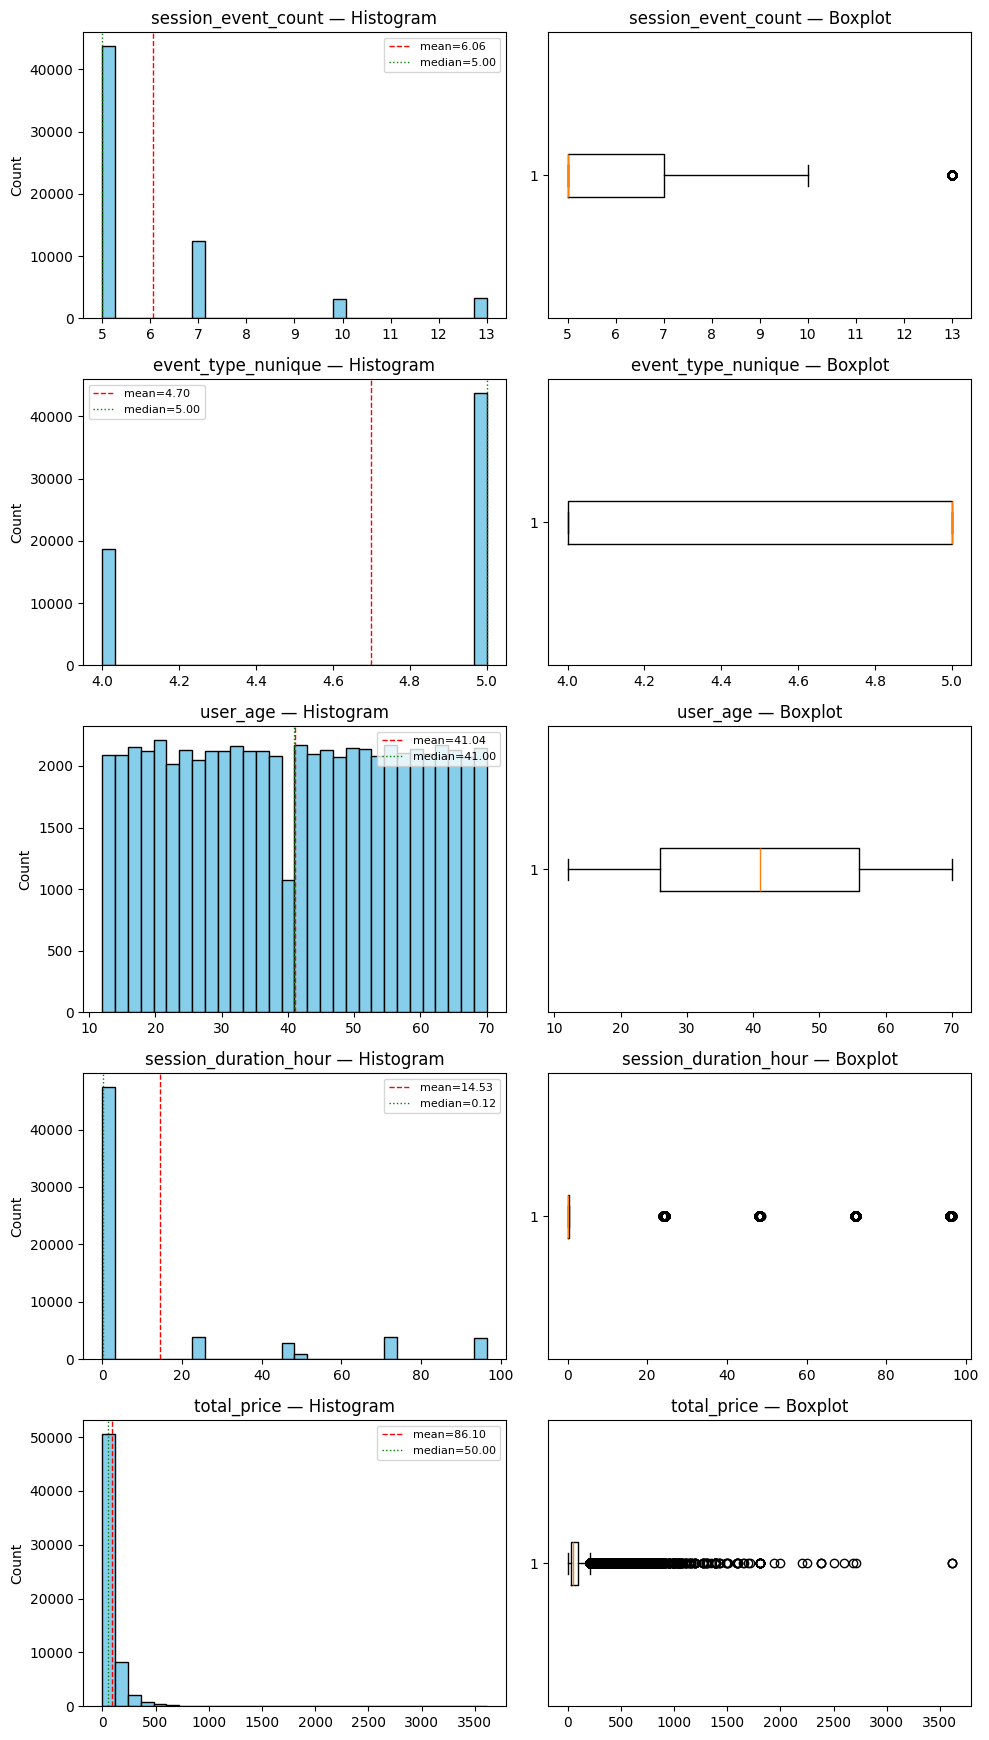

In [16]:
plot_numeric_combo(train_df, int_cols+float_cols)

# 상관 분석

## 수치형 – 수치형
피어슨 상관 행렬 + 히트맵

## 범주형 – 범주형

카이제곱 검정

## 수치형 – 범주형

In [ ]:
# 데이터 전처리 더 필요해 보이는데...ㅇㅂㅇ;;;
